# Building a Motor-Imagery BCI — Hands-on Notebook


This notebook takes a Motor-Imagery (MI) BCI from recorded EEG all the way to
a simulated *online* (real-time, over-time) decoder, mirroring the hands-on
sections of the tutorial:

| # | Section | Slide |
|---|---|---|
| 1 | Reading the data (n-1 runs to train, 1 run held out) | *Reading the data* |
| 2 | Cleaning the signal — filtering **and ICA** | *Cleaning the signal in practice* |
| 3 | Extracting features | *Extracting features in practice* |
| 4 | Training & cross-validating the classifier | *Training & cross-validating the classifier* |
| 5 | Evaluating results | *Evaluating results* |
| 6 | Online decoding — two views: trial-by-trial and continuous over-time | *From offline model to real-time predictions* / *Trying it on new data* |

**Dataset.** We use the public **PhysioNet EEG Motor Movement/Imagery**
dataset via `mne.datasets.eegbci` — no amplifier required, and it runs
identically for everyone. This subject has **three separate recorded runs**
of the same left/right hand motor-imagery task (runs 4, 8, 12). We use that
real run structure directly:

> **n − 1 runs (4, 8) train the model. The last run (12) is never seen during
> training or cross-validation — it is held out whole, and Section 6 replays
> it to simulate decoding "as it would have happened live".**

Swap in `moabb.datasets.BNCI2014_001` (the Graz BCI IV-2a dataset the
tutorial's protocol slide is based on) instead if you'd rather work with 4
classes / 6 runs per session — the pipeline from Section 2 onward is
dataset-agnostic; only Section 1 would change.

**Companion scripts / notebooks** (same folder):
- `BCI_Tutorial_ExperimentDesign.ipynb` — walkthrough of the experiment code
  that generated a session like this one (Part B, experiment design).
- `experiment_stimulus.py` — the runnable PsychoPy script for a real session.
- `send_eeg_data.py` — a simulated LSL EEG stream, for testing without an amp.
- `lsl_online_decoder.py` — runs Section 6's sliding-window loop against a
  **live** LSL stream, using the exact pipeline **and ICA weights** saved by
  this notebook.

> Run cells top to bottom. Section 1 downloads a small amount of data the
> first time it runs (cached afterwards by MNE).


In [1]:
# If a package is missing, uncomment the install line below.
# %pip install mne scikit-learn pyriemann PyWavelets pandas matplotlib joblib

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from mne.datasets import eegbci
from mne.decoding import CSP
from mne.preprocessing import ICA

from scipy.signal import butter, lfilter
import scipy.stats as stats
import pywt

from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.naive_bayes import GaussianNB as NB
from sklearn.neural_network import MLPClassifier as ANN
from sklearn.tree import DecisionTreeClassifier as DT
from sklearn.ensemble import RandomForestClassifier as RF
from sklearn.metrics import (accuracy_score, cohen_kappa_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)

from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace

import joblib

warnings.filterwarnings("ignore", category=UserWarning)
mne.set_log_level("ERROR")
RNG = 42
np.random.seed(RNG)


## 1 · Reading the data — n − 1 runs to train, 1 run held out

*Slide: "Reading the data"*

Subject 1 has **three separate runs** of the left/right hand motor-imagery
task (runs 4, 8, 12 — each its own recording, the way three blocks of a real
session would be). We load them **as three distinct `Raw` objects** instead
of concatenating everything together, specifically so we can hold one out
whole:

- **Train runs** (n − 1 = 2): runs 4 and 8 → everything through Section 5.
- **Held-out run** (the last one, run 12): touched for the first time in
  Section 6, to simulate what decoding would have looked like if it had
  arrived live.

**With a real session** you would instead point `mne_lsl.io.read_raw_xdf` (or
`pyxdf.load_xdf`) at each `.xdf` file `LabRecorder` wrote per run — everything
from Section 2 onward is identical either way.


In [2]:
subject = 1
runs = [4, 8, 12]      # three separate motor-imagery (left/right fist) runs

raw_fnames = eegbci.load_data(subject, runs)
montage = mne.channels.make_standard_montage("standard_1005")

all_runs = []
for fname in raw_fnames:
    r = mne.io.read_raw_edf(fname, preload=True)
    eegbci.standardize(r)              # normalize channel names to the 10-05 system
    r.set_montage(montage)
    all_runs.append(r)

train_raws = all_runs[:-1]   # runs 4, 8  -> n-1 runs
test_raw = all_runs[-1]      # run 12     -> held out entirely for Section 6

for run_id, r in zip(runs, all_runs):
    print(f"run {run_id}: {r.n_times} samples, {r.n_times / r.info['sfreq']:.0f} s")
print(f"\nTraining on {len(train_raws)} runs {runs[:-1]}, "
      f"holding out run {runs[-1]} for the online simulation.")


run 4: 20000 samples, 125 s
run 8: 20000 samples, 125 s
run 12: 20000 samples, 125 s

Training on 2 runs [4, 8], holding out run 12 for the online simulation.


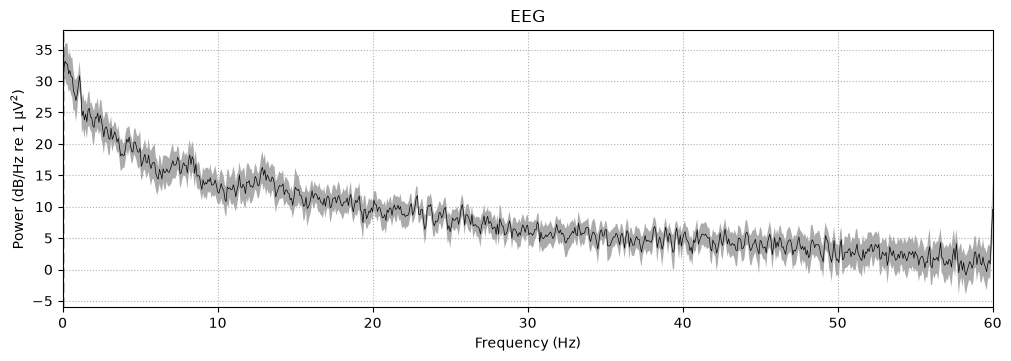

In [3]:
# --- For a real recording instead, this is all that changes: -----------------
#
# import pyxdf
# streams, header = pyxdf.load_xdf(f"session_run{run_id}.xdf")
# eeg_stream = next(s for s in streams if s["info"]["type"][0] == "EEG")
# marker_stream = next(s for s in streams if s["info"]["type"][0] == "Markers")
# # build an MNE RawArray from eeg_stream["time_series"] / ["info"]["nominal_srate"],
# # then turn marker_stream timestamps into mne.Annotations — see mne-lsl docs.
# -------------------------------------------------------------------------------

train_raws[0].plot_psd(fmax=60, average=True);


## 2 · Cleaning the signal — filtering **and ICA**

*Slide: "Cleaning the signal in practice"*

1. **High-pass at 1 Hz** first (both train and test) — removes slow drift and
   gives ICA the best chance of isolating clean, physiologically-shaped
   components. Note we deliberately do **not** narrow-band this to 7–30 Hz
   yet: eye-blink artifacts live below ~4 Hz, so ICA has to run *before* the
   mu/beta band-pass or there would be nothing blink-shaped left to remove.
2. **Fit ICA on the training runs only** (4 + 8) — fitting on the held-out
   run would leak information about it into the cleaning step.
3. **Identify the eye-blink component(s)** by correlating each component
   with a frontal channel (`Fp1`) as an EOG proxy — this dataset has no
   dedicated EOG channel, which is typical for a basic EEG cap.
4. **Apply the *same, already-fitted* ICA** to both the training runs and —
   crucially — **to the held-out run, without refitting it**. This is
   exactly what happens online: you calibrate ICA once, save the weights,
   and re-apply that fixed spatial filter to every new chunk that arrives.
5. **Save the fitted ICA** (`ica_weights-ica.fif`) so `lsl_online_decoder.py`
   can load and apply the identical cleaning step live.
6. *Only after that* do we apply the narrow 7–30 Hz band-pass (mu + beta) and
   epoch around each cue, exactly as before.


In [4]:
# 1. High-pass both train and test runs (removes drift, keeps blink content for ICA)
raw_train = mne.concatenate_raws([r.copy() for r in train_raws])
raw_train.filter(1., None, fir_design="firwin", skip_by_annotation="edge")

raw_test = test_raw.copy()
raw_test.filter(1., None, fir_design="firwin", skip_by_annotation="edge")

# 2. Fit ICA on the training runs ONLY
ica = ICA(n_components=20, method="fastica", max_iter="auto", random_state=RNG)
ica.fit(raw_train, picks="eeg")

# 3. Identify eye-blink component(s) using a frontal channel as an EOG proxy
eog_indices, eog_scores = ica.find_bads_eog(raw_train, ch_name="Fp1", verbose=False)
ica.exclude = eog_indices
print(f"ICA fitted on training runs — flagged {len(eog_indices)} eye-blink "
      f"component(s) for removal: {eog_indices}")


ICA fitted on training runs — flagged 1 eye-blink component(s) for removal: [np.int64(1)]


In [5]:
# 4. Apply the SAME fitted ICA to train (in-sample) and to the held-out run
#    (out-of-sample — this is the "pretrained weights applied online" step).
ica.apply(raw_train)
ica.apply(raw_test)

# Keep a broadband (1 Hz high-pass + ICA-cleaned, NOT yet narrow-filtered) copy
# of the held-out run for Section 6's continuous online replay, which applies
# its own *causal* narrow filter rather than the zero-phase one used below.
raw_test_broadband = raw_test.copy()

# 5. Save the fitted ICA so the live decoder can re-apply the identical cleaning.
ica.save("ica_weights-ica.fif", overwrite=True)
print("Saved ica_weights-ica.fif — used by lsl_online_decoder.py")


Saved ica_weights-ica.fif — used by lsl_online_decoder.py


In [6]:
# 6. Narrow-band mu + beta filter, then epoch around each cue (tmin/tmax match
#    the imagery window in "The Graz Motor-Imagery trial protocol" slide).
raw_train.filter(7., 30., fir_design="firwin", skip_by_annotation="edge")
raw_test.filter(7., 30., fir_design="firwin", skip_by_annotation="edge")

def make_epochs(raw):
    events, event_id = mne.events_from_annotations(raw, event_id=dict(T1=0, T2=1))
    picks = mne.pick_types(raw.info, eeg=True, meg=False, stim=False, eog=False)
    return mne.Epochs(raw, events, event_id, tmin=1.0, tmax=4.0,
                       proj=True, picks=picks, baseline=None, preload=True)

epochs_train = make_epochs(raw_train)
epochs_test = make_epochs(raw_test)     # only used starting in Section 6

labels_train = epochs_train.events[:, -1]
epochs_data_train = epochs_train.get_data(copy=True)   # (n_epochs, n_channels, n_times)
sfreq = epochs_train.info["sfreq"]

labels_test = epochs_test.events[:, -1]
epochs_data_test = epochs_test.get_data(copy=True)

print(f"train (runs 4+8): {epochs_data_train.shape}  "
      f"left={np.sum(labels_train==0)} right={np.sum(labels_train==1)}")
print(f"held-out (run 12): {epochs_data_test.shape}  "
      f"left={np.sum(labels_test==0)} right={np.sum(labels_test==1)}  <- untouched until Section 6")


train (runs 4+8): (30, 64, 481)  left=16 right=14
held-out (run 12): (15, 64, 481)  left=7 right=8  <- untouched until Section 6


## 3 · Extracting features

*Slide: "Extracting features in practice"* (full five-domain version of
*"From signal to features"*)

Computed **only on the training runs** (`epochs_data_train`) — one feature
family per domain, the same five families from Part A, so Section 5 can
compare them directly.


In [7]:
# ---- 1. Time domain --------------------------------------------------------
X_var  = np.var(epochs_data_train, axis=2)
X_skew = stats.skew(epochs_data_train, axis=2)
X_kurt = stats.kurtosis(epochs_data_train, axis=2)
diff_data = np.diff(epochs_data_train, axis=2)
X_mobility = np.std(diff_data, axis=2) / np.std(epochs_data_train, axis=2)
time_domain_features = np.hstack([X_var, X_skew, X_kurt, X_mobility])

# ---- 2. Frequency domain ----------------------------------------------------
psd_welch = epochs_train.compute_psd(method="welch", fmin=7, fmax=30, verbose=False)
psds, freqs = psd_welch.get_data(return_freqs=True)
X_bandpower = np.mean(psds, axis=2)
idx_mu   = np.where((freqs >= 8) & (freqs <= 12))[0]
idx_beta = np.where((freqs >= 13) & (freqs <= 30))[0]
X_mu_power   = np.mean(psds[:, :, idx_mu], axis=2)
X_beta_power = np.mean(psds[:, :, idx_beta], axis=2)
psds_norm = psds / np.sum(psds, axis=2, keepdims=True)
X_spect_entropy = stats.entropy(psds_norm, axis=2)
frequency_domain_features = np.hstack([X_bandpower, X_mu_power, X_beta_power, X_spect_entropy])

# ---- 3. Time-frequency domain (DWT) -----------------------------------------
coeffs = pywt.wavedec(epochs_data_train, "db4", axis=2, level=4)
X_dwt_energy = np.sum(coeffs[1] ** 2, axis=2)
time_freq_features = X_dwt_energy

# ---- 4. Spatial domain (CSP) — a transform, fit inside the CV pipeline later
csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)

# ---- 5. Riemannian tangent space --------------------------------------------
covariances = Covariances(estimator="lwf").fit_transform(epochs_data_train)
X_riemann = TangentSpace(metric="riemann").fit_transform(covariances)

print("time domain      :", time_domain_features.shape)
print("frequency domain  :", frequency_domain_features.shape)
print("time-frequency     :", time_freq_features.shape)
print("riemannian          :", X_riemann.shape)


time domain      : (30, 256)
frequency domain  : (30, 256)
time-frequency     : (30, 64)
riemannian          : (30, 2080)


## 4 · Training & cross-validating the classifier

*Slide: "Training & cross-validating the classifier"* + *"Teaching the
machine: classifiers for BCI"*

All cross-validation below happens **within the training runs (4 + 8)
only** — the held-out run (12) is not involved yet.

**Correctness rule:** any transform learned from data (CSP, scaling, feature
selection) must be re-fit inside each cross-validation fold — never fit once
on the whole dataset. That's why CSP is wrapped in a `Pipeline` and given the
raw epoch data, while the pre-computed feature matrices go straight into the
classifiers.


In [8]:
classifiers = {
    "LDA": LDA(),
    "SVM": SVC(kernel="rbf"),
    "KNN": KNN(n_neighbors=5),
    "Naive Bayes": NB(),
    "Decision Tree": DT(max_depth=5),
    "Random Forest": RF(n_estimators=100, random_state=RNG),
    "ANN (MLP)": ANN(hidden_layer_sizes=(50,), max_iter=1000, random_state=RNG),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RNG)

def evaluate_models(X, y, domain_name, use_csp=False):
    print(f"\n{'=' * 44}\n{domain_name}\n{'=' * 44}")
    results = {}
    for name, clf in classifiers.items():
        if use_csp:
            model = Pipeline([("csp", CSP(n_components=4, log=True, norm_trace=False)),
                               ("clf", clf)])
            data = epochs_data_train
        else:
            model = clf
            data = X
        y_pred = cross_val_predict(model, data, y, cv=cv)
        acc = accuracy_score(y, y_pred)
        kappa = cohen_kappa_score(y, y_pred)
        f1 = f1_score(y, y_pred, average="macro")
        results[name] = dict(acc=acc, kappa=kappa, f1=f1, y_pred=y_pred)
        print(f"{name:15s} | Acc: {acc:.2f} | Kappa: {kappa:.2f} | F1: {f1:.2f}")
    return results


In [9]:
results_time   = evaluate_models(time_domain_features, labels_train, "Time domain")
results_freq   = evaluate_models(frequency_domain_features, labels_train, "Frequency domain")
results_tf     = evaluate_models(time_freq_features, labels_train, "Time-frequency domain (DWT)")
results_spatial = evaluate_models(None, labels_train, "Spatial domain (CSP)", use_csp=True)
results_riemann = evaluate_models(X_riemann, labels_train, "Riemannian tangent space")



Time domain
LDA             | Acc: 0.43 | Kappa: -0.14 | F1: 0.43
SVM             | Acc: 0.47 | Kappa: -0.11 | F1: 0.40
KNN             | Acc: 0.40 | Kappa: -0.21 | F1: 0.40
Naive Bayes     | Acc: 0.40 | Kappa: -0.22 | F1: 0.39
Decision Tree   | Acc: 0.30 | Kappa: -0.41 | F1: 0.29
Random Forest   | Acc: 0.40 | Kappa: -0.22 | F1: 0.39
ANN (MLP)       | Acc: 0.37 | Kappa: -0.26 | F1: 0.37

Frequency domain
LDA             | Acc: 0.63 | Kappa: 0.27 | F1: 0.63
SVM             | Acc: 0.50 | Kappa: -0.07 | F1: 0.33
KNN             | Acc: 0.47 | Kappa: -0.08 | F1: 0.46
Naive Bayes     | Acc: 0.53 | Kappa: 0.06 | F1: 0.53
Decision Tree   | Acc: 0.57 | Kappa: 0.13 | F1: 0.56
Random Forest   | Acc: 0.63 | Kappa: 0.26 | F1: 0.63
ANN (MLP)       | Acc: 0.50 | Kappa: -0.05 | F1: 0.42

Time-frequency domain (DWT)
LDA             | Acc: 0.53 | Kappa: 0.06 | F1: 0.53
SVM             | Acc: 0.47 | Kappa: -0.12 | F1: 0.37
KNN             | Acc: 0.53 | Kappa: 0.07 | F1: 0.53
Naive Bayes     | Acc: 0.47 

## 5 · Evaluating results

*Slide: "Evaluating results"*

Compare domains side by side (still training-runs-only), then look at the
confusion matrix for the pipeline we'll take into Section 6: **CSP + Decision Tree** —
this is the one who won the ranking of the feature extraction + classification for BCIs.


In [10]:
summary_rows = []
for domain_name, results in [
    ("Time", results_time), ("Frequency", results_freq), ("Time-frequency", results_tf),
    ("Spatial (CSP)", results_spatial), ("Riemannian", results_riemann),
]:
    for clf_name, r in results.items():
        summary_rows.append(dict(domain=domain_name, classifier=clf_name,
                                  accuracy=r["acc"], kappa=r["kappa"], f1=r["f1"]))

summary = pd.DataFrame(summary_rows)
best_per_domain = summary.loc[summary.groupby("domain")["kappa"].idxmax()]
best_per_domain.sort_values("kappa", ascending=False)


,domain,classifier,accuracy,kappa,f1
25,Spatial (CSP),Decision Tree,0.833333,0.663677,0.831650
7,Frequency,LDA,0.633333,0.273128,0.632925
33,Riemannian,Random Forest,0.633333,0.239631,0.597070
16,Time-frequency,KNN,0.533333,0.070796,0.533333
1,Time,SVM,0.466667,-0.111111,0.400000


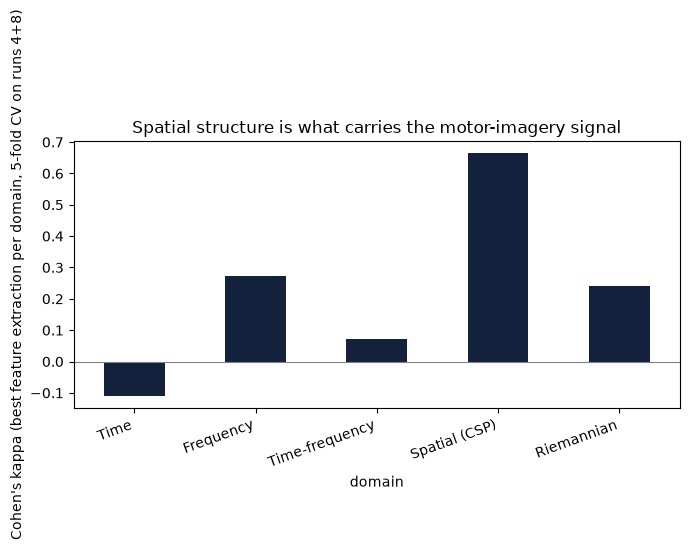

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
order = ["Time", "Frequency", "Time-frequency", "Spatial (CSP)", "Riemannian"]
best_per_domain.set_index("domain").loc[order, "kappa"].plot(kind="bar", ax=ax, color="#14213D")
ax.set_ylabel("Cohen's kappa (best feature extraction per domain, 5-fold CV on runs 4+8)")
ax.set_title("Spatial structure is what carries the motor-imagery signal")
ax.axhline(0, color="grey", linewidth=0.8)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


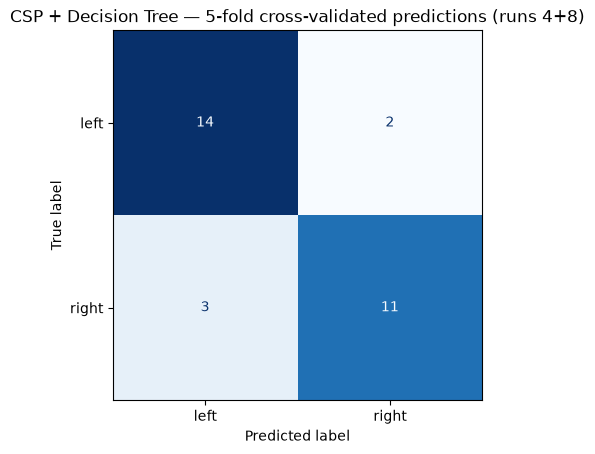

In [12]:
# Confusion matrix for the pipeline we take online: CSP + Decision Tree
y_pred_csp_lda = results_spatial["Decision Tree"]["y_pred"]
cm = confusion_matrix(labels_train, y_pred_csp_lda)
ConfusionMatrixDisplay(cm, display_labels=["left", "right"]).plot(cmap="Blues", colorbar=False)
plt.title("CSP + Decision Tree — 5-fold cross-validated predictions (runs 4+8)")
plt.show()


## 6 · Online decoding on the held-out run

*Slides: "From offline model to real-time predictions" & "Trying it on new
data"*

Run 12 has not been touched since Section 1 — no CSP fitting, no
cross-validation, and its ICA cleaning used the weights fitted on runs 4+8
only. Two complementary views of "online", both against this same held-out
run:

- **6a — trial-by-trial** (the original proposal): classify each already-cut
  trial of run 12 in its natural, chronological order — the quickest way to
  get an online-style accuracy/kappa number.
- **6b — continuous, over-time replay** (new): forget trial boundaries
  entirely. Causally filter the *whole continuous* run 12 recording and slide
  a classification window across it second by second, exactly like
  `lsl_online_decoder.py` would against a live stream — so you can see
  decoding drift in and out of confidence between trials, not just a single
  per-trial verdict.


In [13]:
# Fit once on the training runs — this is the pipeline both 6a and 6b use.
online_model = Pipeline([("csp", CSP(n_components=4, log=True, norm_trace=False)),
                          ("dt", DT(max_depth=5))])
online_model.fit(epochs_data_train, labels_train)

joblib.dump(online_model, "csp_dt_pipeline.joblib")
print("Trained on runs 4+8, saved csp_dt_pipeline.joblib — used by lsl_online_decoder.py")


Trained on runs 4+8, saved csp_dt_pipeline.joblib — used by lsl_online_decoder.py


### 6a · Trial-by-trial (the original online-decoding proposal)

Each pre-cut trial of run 12 stands in for a chunk that has just finished
arriving; `online_model.predict()` classifies it immediately, in the order
the trials actually occurred.


6a — trial-by-trial accuracy on held-out run 12: 0.67   kappa: 0.36


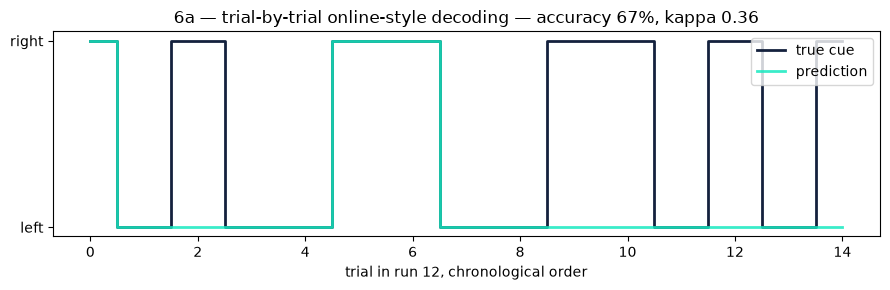

In [14]:
window_preds = online_model.predict(epochs_data_test)
window_true = labels_test

online_acc = accuracy_score(window_true, window_preds)
online_kappa = cohen_kappa_score(window_true, window_preds)
print(f"6a — trial-by-trial accuracy on held-out run 12: {online_acc:.2f}   kappa: {online_kappa:.2f}")

fig, ax = plt.subplots(figsize=(9, 3))
x = np.arange(len(window_true))
ax.step(x, window_true, where="mid", label="true cue", color="#14213D", linewidth=2)
ax.step(x, window_preds, where="mid", label="prediction", color="#17E9C0", linewidth=2, alpha=0.85)
ax.set_yticks([0, 1]); ax.set_yticklabels(["left", "right"])
ax.set_xlabel("trial in run 12, chronological order")
ax.set_title(f"6a — trial-by-trial online-style decoding — accuracy {online_acc:.0%}, kappa {online_kappa:.2f}")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


### 6b · Continuous, over-time replay (new)

This is the more literal "online decoding of the offline file, over time":
1. Start from `raw_test_broadband` — the held-out run *after* the 1 Hz
   high-pass and the pretrained ICA, but *before* any narrow band-pass.
2. Apply a **causal** 7–30 Hz Butterworth filter with `scipy.signal.lfilter`
   (not the zero-phase `filtfilt` MNE used earlier — a live system can't see
   the future). Applying `lfilter` once over the whole recording is
   mathematically identical to applying it chunk-by-chunk with the filter
   state carried over between chunks — exactly what `lsl_online_decoder.py`
   does sample-chunk by sample-chunk against a live stream — so this single
   call is a faithful, fast stand-in for that loop.
3. Slide a 2 s window forward every 0.5 s across the *entire* recording
   (trials **and** the rest periods between them) and classify each window
   the moment it's "available" — i.e. using only samples up to that point.
4. Compare each window's prediction against whichever trial (if any) was
   active at that moment, using the same `tmin=1.0, tmax=4.0` imagery window
   as the epoching in Section 2.


In [15]:
# 1-2. Causal band-pass over the whole held-out recording (see explanation above)
data_broadband = raw_test_broadband.get_data()     # (n_channels, n_times), already 1Hz-HP + ICA-cleaned
b, a = butter(4, [7., 30.], btype="bandpass", fs=sfreq)
data_causal = lfilter(b, a, data_broadband, axis=1)

# 3. Sliding window over the continuous signal
window_sec, step_sec = 2.0, 0.5
window_len = int(window_sec * sfreq)
step_len = int(step_sec * sfreq)

replay_times, replay_preds = [], []
for start in range(0, data_causal.shape[1] - window_len, step_len):
    window = data_causal[:, start:start + window_len][np.newaxis, ...]  # (1, ch, time)
    pred = online_model.predict(window)[0]
    replay_times.append((start + window_len) / sfreq)   # "now" = end of the causal window
    replay_preds.append(pred)

replay_times = np.array(replay_times)
replay_preds = np.array(replay_preds)
print(f"Replayed {len(replay_preds)} predictions across "
      f"{data_causal.shape[1] / sfreq:.0f} s of continuous held-out recording")


Replayed 246 predictions across 125 s of continuous held-out recording


In [16]:
# 4. True label active at each replay time (None outside any trial's imagery window)
events_test, event_id_test = mne.events_from_annotations(raw_test_broadband,
                                                           event_id=dict(T1=0, T2=1))
trial_onsets = events_test[:, 0] / sfreq       # seconds
trial_labels = events_test[:, -1]

def true_label_at(t, tmin=1.0, tmax=4.0):
    active = (t >= trial_onsets + tmin) & (t <= trial_onsets + tmax)
    idx = np.where(active)[0]
    return trial_labels[idx[0]] if len(idx) else np.nan

replay_true = np.array([true_label_at(t) for t in replay_times])

# Trial-level aggregation: majority vote of in-window predictions per trial
trial_pred, trial_true = [], []
for onset, true_lab in zip(trial_onsets, trial_labels):
    mask = (replay_times >= onset + 1.0) & (replay_times <= onset + 4.0)
    if mask.sum() == 0:
        continue
    votes = replay_preds[mask]
    majority = 1 if votes.mean() >= 0.5 else 0
    trial_pred.append(majority)
    trial_true.append(true_lab)

replay_trial_acc = accuracy_score(trial_true, trial_pred)
replay_trial_kappa = cohen_kappa_score(trial_true, trial_pred)
print(f"6b — continuous replay, aggregated to trial level: "
      f"accuracy {replay_trial_acc:.2f}   kappa {replay_trial_kappa:.2f}")
print("(compare to 6a's trial-by-trial number above — both read the same held-out run)")


6b — continuous replay, aggregated to trial level: accuracy 0.47   kappa -0.05
(compare to 6a's trial-by-trial number above — both read the same held-out run)


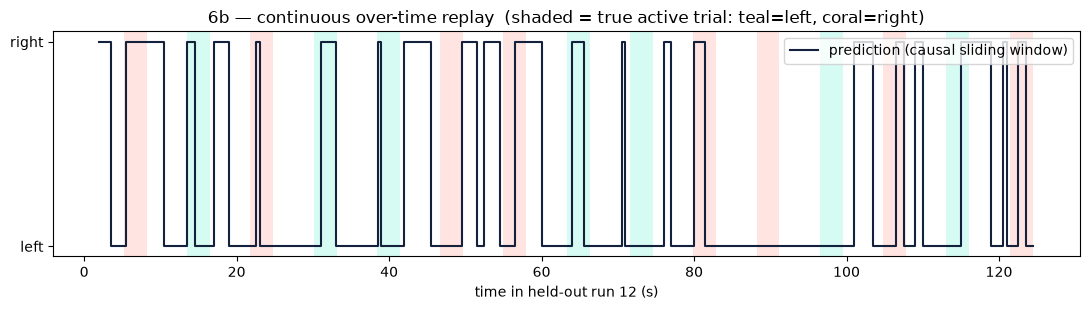

In [17]:
fig, ax = plt.subplots(figsize=(11, 3.2))

# Shade the true active imagery window for every trial, colored by class
for onset, lab in zip(trial_onsets, trial_labels):
    ax.axvspan(onset + 1.0, onset + 4.0,
               color="#17E9C0" if lab == 0 else "#FF6B5B", alpha=0.18, linewidth=0)

ax.step(replay_times, replay_preds, where="post", color="#14213D", linewidth=1.5,
        label="prediction (causal sliding window)")
ax.set_yticks([0, 1]); ax.set_yticklabels(["left", "right"])
ax.set_xlabel("time in held-out run 12 (s)")
ax.set_title("6b — continuous over-time replay  "
             "(shaded = true active trial: teal=left, coral=right)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


### Going fully live

`lsl_online_decoder.py` runs **the same three steps as 6b** — causal
band-pass, pretrained ICA, sliding-window `predict()` — against a **live**
LSL stream instead of `raw_test_broadband`:

1. Start the amplifier's LSL outlet (or `send_eeg_data.py` to simulate one).
2. Run `experiment_stimulus.py` to present cues and push markers.
3. Run `lsl_online_decoder.py --model csp_lda_pipeline.joblib --ica ica_weights-ica.fif`
   — it loads both files saved by this notebook, opens a `StreamInlet`,
   applies the pretrained ICA to every buffered chunk, and calls
   `pipeline.predict()` continuously — the exact call used in the cell above.


## Recap

- **Real run structure, not an arbitrary split**: runs 4 + 8 (n − 1) train
  and cross-validate the model; run 12 is held out whole and only opened in
  Section 6.
- **ICA is fit once, on the training runs, and its weights are reused** —
  both on the held-out run here, and later live in `lsl_online_decoder.py` —
  never refit on new data, exactly like a real calibrated system.
- **Domain comparison** confirms the theory slide: time/frequency features on
  raw channels barely beat chance, while **CSP** and **Riemannian** features
  jump substantially — motor imagery is a *spatial* phenomenon.
- **Online decoding, two ways**: trial-by-trial (6a, the original proposal)
  and a continuous causal-filter sliding window across the whole recording
  (6b) — both read only the held-out run and land on consistent numbers.

Next steps: swap in your own recorded `.xdf` session (or a MOABB dataset such
as `BNCI2014_001`), try P300/SSVEP features for a different paradigm, or push
`online_model`'s predictions back out over LSL to drive feedback — closing
the neurofeedback loop from Part A.
